# Water Level Prediction using Graph Convolutional Neural Networks (GCNN)

This notebook demonstrates how to load water level and temperature data, fill missing values, build a spatial graph of the stations, and train a Graph Convolutional Neural Network (GCNN) using PyTorch Geometric to predict the mean water level of the following day. It also compares the GCNN performance to a simple persistence model.

## 1. Imports


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_squared_error, mean_absolute_error


/Users/andrewparnell/Documents/GitHub/STAT41130/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data and Parse Metadata

We will read the metadata from the top of the CSV files (the first 12 rows) to extract the latitude and longitude of each station. Then we merge the water level (`S`) and water temperature (`TWater`) data.


In [4]:
def load_station_data(directory):
    # Dictionaries to store data
    water_levels = {}
    water_temps = {}
    station_metadata = {}
    
    # Get all CSV files
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    
    for filepath in all_files:
        filename = os.path.basename(filepath)
        metadata = {}
        
        # Parse the 12 header lines
        with open(filepath, 'r') as f:
            for i in range(12):
                line = f.readline().strip()
                if line.startswith('#'):
                    parts = line[1:].split(':', 1)
                    if len(parts) == 2:
                        metadata[parts[0].strip()] = parts[1].strip()
        
        # Identify station ID and parameter
        station_id = metadata.get('Station Number', 'Unknown')
        param = metadata.get('Station Parameter Name', '')
        
        # Save metadata (latitude and longitude)
        if station_id not in station_metadata:
            try:
                station_metadata[station_id] = {
                    'name': metadata.get('Station Name', ''),
                    'lat': float(metadata.get('Latitude', 0)),
                    'lon': float(metadata.get('Longitude', 0))
                }
            except ValueError:
                pass 
        
        # Load the CSV data, skipping the 12 header lines
        try:
            df = pd.read_csv(filepath, skiprows=12)
            df['Day'] = pd.to_datetime(df['Day'], format='%d/%m/%Y')
            df.set_index('Day', inplace=True)
            
            # We only keep the 'Day Mean'
            if param == 'S': 
                water_levels[station_id] = df[['Day Mean']].rename(columns={'Day Mean': station_id})
            elif param == 'TWater': 
                water_temps[station_id] = df[['Day Mean']].rename(columns={'Day Mean': station_id})
        except Exception as e:
            print(f"Could not parse data for {filename}: {e}")
            
    # Combine into single dataframes
    if len(water_levels) > 0:
        df_levels = pd.concat(water_levels.values(), axis=1)
    else:
        df_levels = pd.DataFrame()
        
    if len(water_temps) > 0:
        df_temps = pd.concat(water_temps.values(), axis=1)
    else:
        df_temps = pd.DataFrame()
        
    return df_levels, df_temps, station_metadata

# Provide the directory where your CSV files are located. 
# Here we use the current directory '.' as default.
DATA_DIR = '../../data/water_level'  # Change this to your actual data directory
df_levels, df_temps, station_metadata = load_station_data(DATA_DIR)

print(f"Loaded data for {len(station_metadata)} stations.")
if not df_levels.empty:
    print("Water Level Data shape:", df_levels.shape)
if not df_temps.empty:
    print("Water Temp Data shape:", df_temps.shape)


Loaded data for 5 stations.
Water Level Data shape: (365, 5)
Water Temp Data shape: (365, 5)


## 3. Impute Missing Values and Basic Time Series Plots

We fill missing values using a simple median imputation along each column (representing each station).


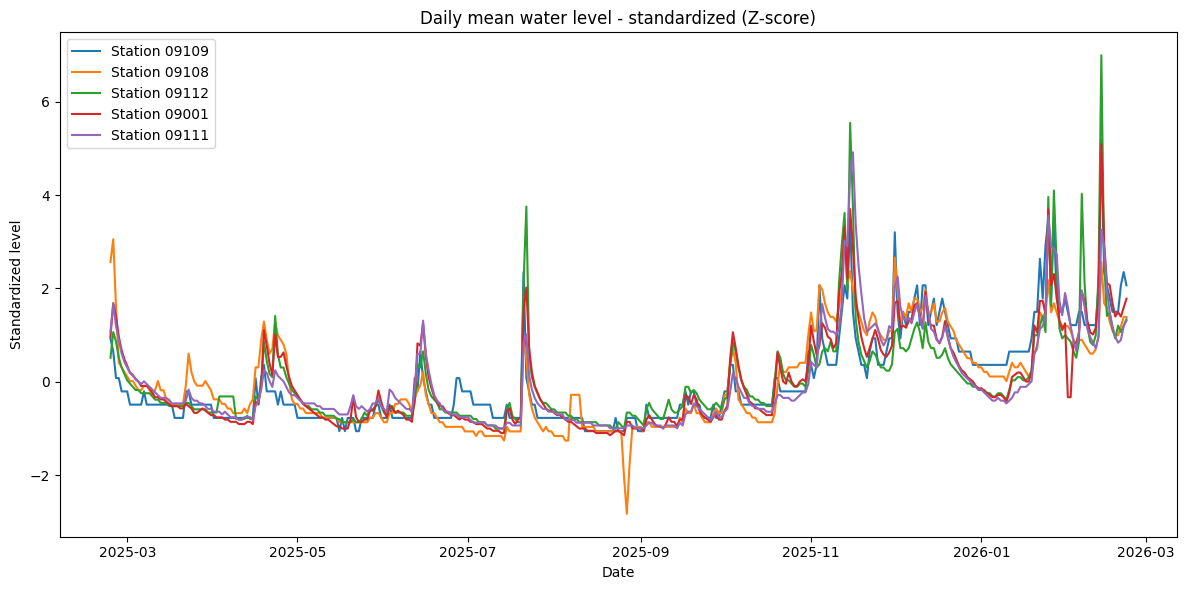

In [15]:
# Fill missing values with the median of each column
df_levels_filled = df_levels.fillna(df_levels.median())
df_temps_filled = df_temps.fillna(df_temps.median())

# Standardize the data (Z-score normalization)
# We overwrite the filled dataframes so downstream code continues to work seamlessly
df_levels_filled = (df_levels_filled - df_levels_filled.mean()) / df_levels_filled.std()
df_temps_filled = (df_temps_filled - df_temps_filled.mean()) / df_temps_filled.std()

# Plot the standardized water levels for all available stations
plt.figure(figsize=(12, 6))
for col in df_levels_filled.columns:
    plt.plot(df_levels_filled.index, df_levels_filled[col], label=f'Station {col}')
    
plt.title('Daily mean water level - standardized (Z-score)')
plt.xlabel('Date')
plt.ylabel('Standardized level')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Graph Construction

We create an adjacency matrix using the Haversine distance between stations. The edge weights are calculated using an exponential decay function: $w_{ij} = e^{-d_{ij} / \sigma}$


In [16]:
def haversine(lat1, lon1, lat2, lon2):
    # Earth radius in kilometers
    R = 6371.0 
    
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    
    a = np.sin(dLat / 2)**2 + \
        np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

# We need a fixed ordering of stations to map them to node indices
station_ids = list(station_metadata.keys())
num_nodes = len(station_ids)

# Calculate distances
dist_matrix = np.zeros((num_nodes, num_nodes))
for i, id1 in enumerate(station_ids):
    for j, id2 in enumerate(station_ids):
        if i != j:
            lat1, lon1 = station_metadata[id1]['lat'], station_metadata[id1]['lon']
            lat2, lon2 = station_metadata[id2]['lat'], station_metadata[id2]['lon']
            dist_matrix[i, j] = haversine(lat1, lon1, lat2, lon2)

# Convert distance to edge weights (exponential decay)
sigma = 10.0 # Control the scale of the distance effect
weight_matrix = np.exp(-dist_matrix / sigma)

# Remove self loops for the explicit edge list (GCNConv handles self loops internally)
np.fill_diagonal(weight_matrix, 0)

# Create edge_index and edge_attr for PyTorch Geometric
edge_indices = []
edge_weights = []

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j and weight_matrix[i, j] > 0.01: # Threshold to drop very weak connections
            edge_indices.append([i, j])
            edge_weights.append(weight_matrix[i, j])

if len(edge_indices) > 0:
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float)
else:
    # Fallback if only 1 station is loaded or no edges pass threshold
    edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.empty((0,), dtype=torch.float)

print("Edge Index Shape:", edge_index.shape)
print("Number of Nodes:", num_nodes)


Edge Index Shape: torch.Size([2, 20])
Number of Nodes: 5


## 5. Prepare Temporal Dataset

We formulate the prediction task as predicting the next day water level given the current day water level and temperature. We will split the sequence chronologically into 80 percent training data and 20 percent testing data.


In [17]:
# Create node features X and targets Y for each timestep
# X shape: [time_steps, num_nodes, num_features (2)]
# Y shape: [time_steps, num_nodes, 1]

# Find common dates
common_dates = df_levels_filled.index.intersection(df_temps_filled.index).sort_values()

# If missing temperature data for some stations, fill with 0 to keep shape consistent
for sid in station_ids:
    if sid not in df_temps_filled.columns:
        df_temps_filled[sid] = 0.0
    if sid not in df_levels_filled.columns:
        df_levels_filled[sid] = 0.0

X_list = []
Y_list = []

for t in range(len(common_dates) - 1):
    current_date = common_dates[t]
    next_date = common_dates[t+1]
    
    x_t = []
    y_t = []
    
    for sid in station_ids:
        level = df_levels_filled.loc[current_date, sid]
        temp = df_temps_filled.loc[current_date, sid]
        target_level = df_levels_filled.loc[next_date, sid]
        
        x_t.append([level, temp])
        y_t.append([target_level])
        
    X_list.append(x_t)
    Y_list.append(y_t)

X_tensor = torch.tensor(X_list, dtype=torch.float)
Y_tensor = torch.tensor(Y_list, dtype=torch.float)

# Train and Test Split (80/20 chronological)
split_idx = int(len(X_tensor) * 0.8)

X_train, Y_train = X_tensor[:split_idx], Y_tensor[:split_idx]
X_test, Y_test = X_tensor[split_idx:], Y_tensor[split_idx:]
test_dates = common_dates[split_idx:len(common_dates)-1]

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train samples: 291, Test samples: 73


## 6. Define the GCNN Model

We create a simple Graph Convolutional Neural Network. It uses `GCNConv` which performs the message passing and local update steps based on the edge weights we defined via physical distance.


In [18]:
class WaterLevelGCNN(torch.nn.Module):
    def __init__(self, num_node_features):
        super(WaterLevelGCNN, self).__init__()
        # First Graph Convolutional Layer
        self.conv1 = GCNConv(num_node_features, 16)
        # Second Graph Convolutional Layer maps hidden features to 1 output (water level)
        self.conv2 = GCNConv(16, 1)

    def forward(self, x, edge_index, edge_weight):
        # Apply first convolution and ReLU activation
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        
        # Apply second convolution
        x = self.conv2(x, edge_index, edge_weight)
        return x

model = WaterLevelGCNN(num_node_features=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

print(model)


WaterLevelGCNN(
  (conv1): GCNConv(2, 16)
  (conv2): GCNConv(16, 1)
)


## 7. Training the GCNN

We iterate through the training days. For each day, we pass the graph snapshot into the model, calculate the Mean Squared Error (MSE) compared to the actual water level for the next day, and backpropagate the errors.


In [19]:
epochs = 500
model.train()

# If there are no edges (e.g., only 1 station is placed in the folder), 
# GCNConv treats it as isolated nodes, acting as a linear transformation. 

for epoch in range(epochs):
    total_loss = 0
    
    for t in range(X_train.shape[0]):
        optimizer.zero_grad()
        
        x = X_train[t]
        y_true = Y_train[t]
        
        # Forward pass
        y_pred = model(x, edge_index, edge_attr)
        
        # Calculate loss
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / X_train.shape[0]
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss (MSE): {avg_loss:.4f}")


Epoch 010 | Train Loss (MSE): 0.1662
Epoch 020 | Train Loss (MSE): 0.1644
Epoch 030 | Train Loss (MSE): 0.1654
Epoch 040 | Train Loss (MSE): 0.1642
Epoch 050 | Train Loss (MSE): 0.1639
Epoch 060 | Train Loss (MSE): 0.1638
Epoch 070 | Train Loss (MSE): 0.1637
Epoch 080 | Train Loss (MSE): 0.1637
Epoch 090 | Train Loss (MSE): 0.1637
Epoch 100 | Train Loss (MSE): 0.1638
Epoch 110 | Train Loss (MSE): 0.1639
Epoch 120 | Train Loss (MSE): 0.1638
Epoch 130 | Train Loss (MSE): 0.1637
Epoch 140 | Train Loss (MSE): 0.1637
Epoch 150 | Train Loss (MSE): 0.1637
Epoch 160 | Train Loss (MSE): 0.1637
Epoch 170 | Train Loss (MSE): 0.1637
Epoch 180 | Train Loss (MSE): 0.1637
Epoch 190 | Train Loss (MSE): 0.1637
Epoch 200 | Train Loss (MSE): 0.1638
Epoch 210 | Train Loss (MSE): 0.1638
Epoch 220 | Train Loss (MSE): 0.1638
Epoch 230 | Train Loss (MSE): 0.1638
Epoch 240 | Train Loss (MSE): 0.1638
Epoch 250 | Train Loss (MSE): 0.1637
Epoch 260 | Train Loss (MSE): 0.1638
Epoch 270 | Train Loss (MSE): 0.1638
E

## 8. Evaluate and Compare against Persistence Model

A classic baseline in weather and hydrology forecasting is the **Persistence Model**: predicting that the value for tomorrow will be exactly the same as the value for today. We evaluate both models on the test set.


In [20]:
model.eval()
gcnn_predictions = []
persistence_predictions = []
actual_values = []

with torch.no_grad():
    for t in range(X_test.shape[0]):
        x = X_test[t]
        y_true = Y_test[t]
        
        # GCNN Prediction
        y_pred = model(x, edge_index, edge_attr)
        gcnn_predictions.append(y_pred.numpy())
        
        # Persistence Prediction (Feature index 0 is today's water level)
        y_persistence = x[:, 0].unsqueeze(1)
        persistence_predictions.append(y_persistence.numpy())
        
        actual_values.append(y_true.numpy())

# Convert to numpy arrays for easier metrics calculation
# Shape: [time_steps, num_nodes, 1]
gcnn_predictions = np.array(gcnn_predictions)
persistence_predictions = np.array(persistence_predictions)
actual_values = np.array(actual_values)

# Calculate metrics across all stations
gcnn_mse = mean_squared_error(actual_values.flatten(), gcnn_predictions.flatten())
gcnn_mae = mean_absolute_error(actual_values.flatten(), gcnn_predictions.flatten())

pers_mse = mean_squared_error(actual_values.flatten(), persistence_predictions.flatten())
pers_mae = mean_absolute_error(actual_values.flatten(), persistence_predictions.flatten())

print("=== Evaluation on Test Set ===")
print(f"GCNN Model        - MSE: {gcnn_mse:.4f}, MAE: {gcnn_mae:.4f}")
print(f"Persistence Model - MSE: {pers_mse:.4f}, MAE: {pers_mae:.4f}")


=== Evaluation on Test Set ===
GCNN Model        - MSE: 0.4250, MAE: 0.3670
Persistence Model - MSE: 0.4834, MAE: 0.3257


## 9. Plotting the Results

Let us visualize the actual water levels against the predictions of both models for the first station in our dataset.


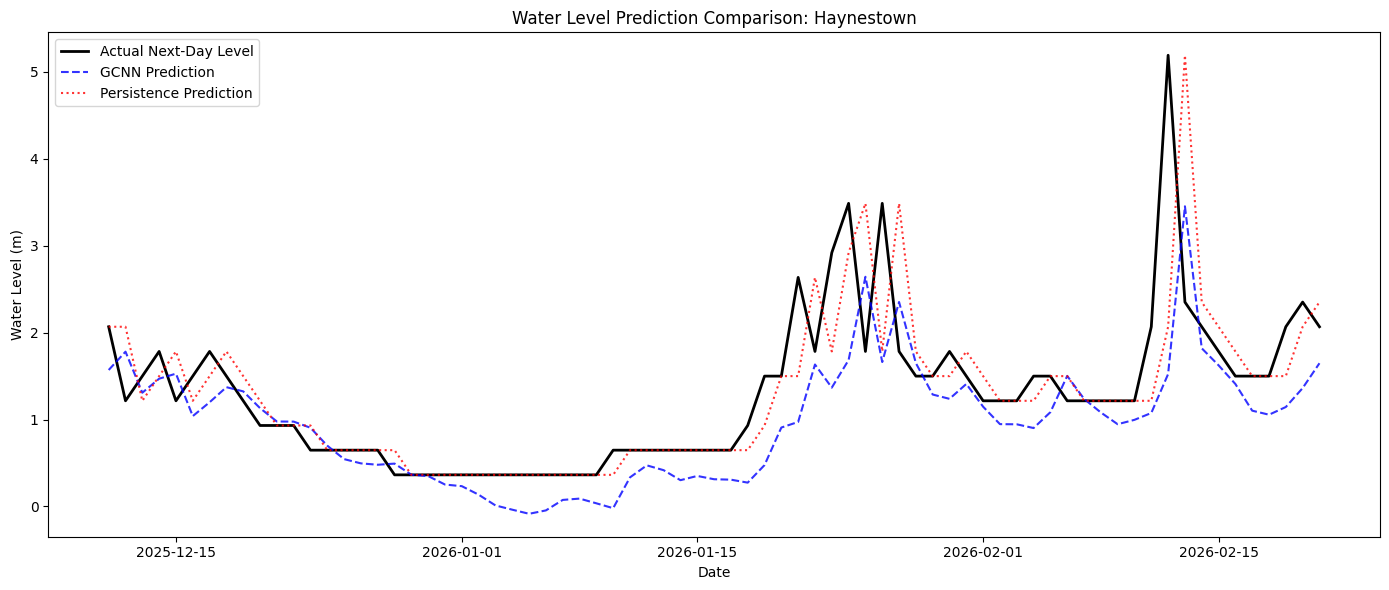

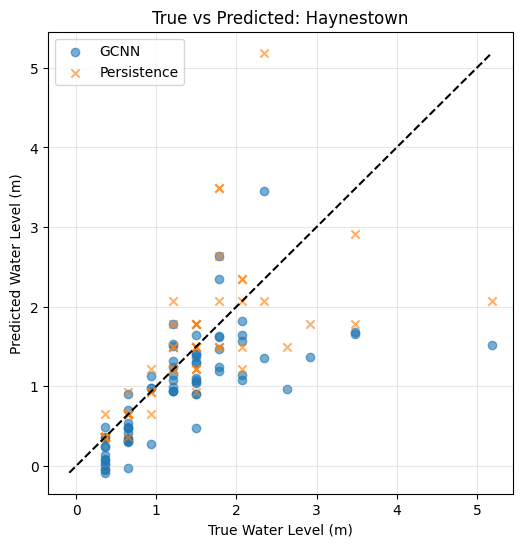

In [21]:
target_station_idx = 0
station_name = station_metadata[station_ids[target_station_idx]]['name']

# Extract data for the single station
actual_station = actual_values[:, target_station_idx, 0]
gcnn_station = gcnn_predictions[:, target_station_idx, 0]
pers_station = persistence_predictions[:, target_station_idx, 0]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actual_station, label='Actual Next-Day Level', color='black', linewidth=2)
plt.plot(test_dates, gcnn_station, label='GCNN Prediction', color='blue', linestyle='--', alpha=0.8)
plt.plot(test_dates, pers_station, label='Persistence Prediction', color='red', linestyle=':', alpha=0.8)

plt.title(f'Water Level Prediction Comparison: {station_name}')
plt.xlabel('Date')
plt.ylabel('Water Level (m)')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter plot of True vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(actual_station, gcnn_station, alpha=0.6, label='GCNN')
plt.scatter(actual_station, pers_station, alpha=0.6, label='Persistence', marker='x')

# Ideal diagonal line
min_val = min(actual_station.min(), gcnn_station.min(), pers_station.min())
max_val = max(actual_station.max(), gcnn_station.max(), pers_station.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.title(f'True vs Predicted: {station_name}')
plt.xlabel('True Water Level (m)')
plt.ylabel('Predicted Water Level (m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
